<a href="https://colab.research.google.com/github/martinabergonzoni/RILEVAMENTO-DELLE-FAKE-NEWS-PER-IL-GOVERNO-DEGLU-USA/blob/main/Rilevamento_delle_Fake_News_per_il_Governo_degli_Stati_Uniti.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Environment setup

In [ ]:
!pip install scikit-learn nltk pandas seaborn matplotlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import Pipeline

import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

import re, string
import requests, io
from zipfile import ZipFile
import pickle

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


# Data load

In [ ]:
print("Downloading data in progress...")
url = "https://proai-datasets.s3.eu-west-3.amazonaws.com/fake_news.zip"
r = requests.get(url)
z = ZipFile(io.BytesIO(r.content))

real = pd.read_csv(z.open("True.csv"))
fake = pd.read_csv(z.open("Fake.csv"))

real["label"] = 0
fake["label"] = 1

# Combine datasets
df = pd.concat([real, fake], ignore_index=True)

# I combine title and text to give the model the full context
df["text"] = (df["title"].fillna("") + " " + df["text"].fillna("")).str.strip()

print(f"Dataset loaded: {df.shape[0]} total items")

Dataset loaded: 44898 total items


# Exploratory analysis

Class distribution

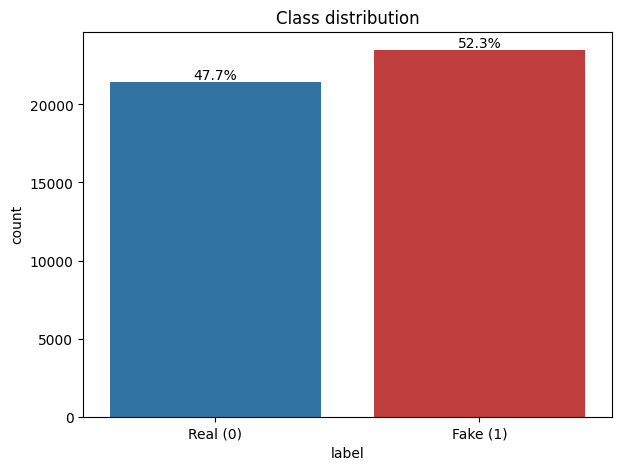

In [ ]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
ax = sns.countplot(data=df, x="label", hue="label", palette={0: '#1f77b4', 1: '#d62728'}, legend=False)
plt.xticks([0,1], ["Real (0)", "Fake (1)"])
plt.title("Class distribution")

total = len(df)
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total)
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom')



Categories

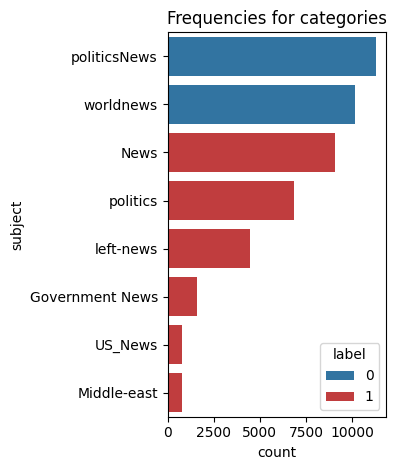

In [ ]:
if "subject" in df.columns:
    plt.subplot(1, 2, 2)

    sns.countplot(data=df, y="subject", hue="label", palette={0: '#1f77b4', 1: '#d62728'}, order=df['subject'].value_counts().index)
    plt.title("Frequencies for categories")

plt.tight_layout()
plt.show()

Title length

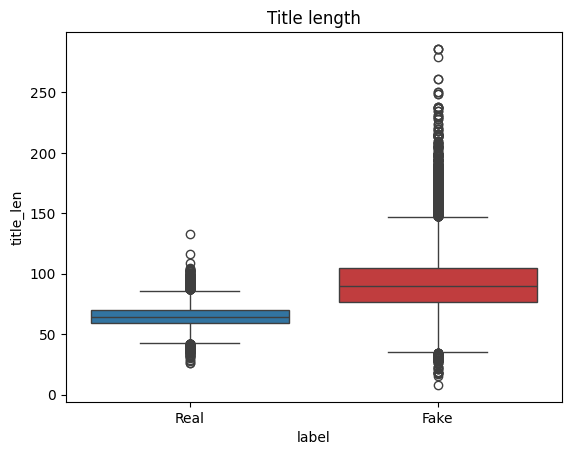

In [ ]:
df["title_len"] = df["title"].fillna("").str.len()

sns.boxplot(data=df, x="label", y="title_len", hue="label", palette={0: '#1f77b4', 1: '#d62728'}, legend=False)
plt.xticks([0,1], ["Real", "Fake"])
plt.title("Title length")
plt.show()

# Preprocessing NLP

In [ ]:
stop_words = set(stopwords.words("english"))

def hard_clean_text(text):
    text = str(text)

    # Remove dateline
    text = re.sub(r'^[\w\s,()]{2,25}\s*-\s*', '', text)
    text = text.lower()

    # Remove the word 'reuters'
    text = re.sub(r'\breuters\b', ' ', text)
    text = re.sub(r"http\S+|www\S+"," ", text)
    text = re.sub(r"[^a-z\s]", " ", text)

    # Truncation
    tokens = [w for w in text.split() if w not in stop_words and len(w) > 2]
    tokens = tokens[:200]

    return " ".join(tokens)

df["clean_text"] = df["text"].apply(hard_clean_text)

# Train test split

In [ ]:
X = df["clean_text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Optimization

In [ ]:
# I create a single pipeline that does both vectorization and classification
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1,2), max_df=0.4, min_df=10)),
    ('svm', LinearSVC(class_weight="balanced", random_state=42))
])

# I define the hyperparameters to test
param_grid = {'svm__C': [0.1, 1, 10]}

print("Training and optimization in progress...")
grid_search = GridSearchCV(pipeline, param_grid, cv=3, scoring='f1_macro', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print(f"The best parameter finds for SMV: {grid_search.best_params_}")

Training and optimization in progress...
Fitting 3 folds for each of 3 candidates, totalling 9 fits


# Model evaluation



In [ ]:
pred = best_model.predict(X_test)

print("\nClassification Report")
print(classification_report(y_test, pred, target_names=["Real","Fake"]))

# Confusion matrix
cm = confusion_matrix(y_test, pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Real","Fake"], yticklabels=["Real","Fake"])
plt.title("Confusion Matrix")
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Interpretation: I find the most associated words

In [ ]:
tfidf_step = best_model.named_steps['tfidf']
svm_step = best_model.named_steps['svm']

feature_names = np.array(tfidf_step.get_feature_names_out())
coef = svm_step.coef_[0]

top_fake = feature_names[np.argsort(coef)[-20:]]
top_real = feature_names[np.argsort(coef)[:20]]

print("Words most associated with FAKE news:\n", top_fake)
print("\nWords most associated with REAL news:\n", top_real)

# Export template for plug‑in

In [ ]:
# Save files
model_filename = "fake_news_pipeline.pkl"

with open(model_filename, "wb") as f:
    pickle.dump(best_model, f)

print(f"\nModel optimizated saved as '{model_filename}'")

# Download
try:
    from google.colab import files
    files.download(model_filename)
except ImportError:
    pass